# Notebook 03: Multi-Stage Sentiment Analysis
## Research Question 1: How can NLP extract meaningful sentiment signals from Amazon product reviews?

This notebook implements a four-stage sentiment analysis pipeline: VADER lexicon baseline, RoBERTa contextual classification, aspect identification using an empirically developed lexicon, and DeBERTa aspect sentiment classification.

**Input:** reviews_cleaned.csv — 93,052 verified reviews  
**Output:** reviews_scored.csv · aspect_sentiment.csv · 3 figures at 300 dpi · 6 summary tables

# Environment setup and loading of the cleaned corpus

In [15]:
# Step 1: Environment setup and loading of the cleaned corpus
# Google Drive is mounted, the VADER lexicon is downloaded, and the
# cleaned corpus produced in the preprocessing stage is loaded.

from google.colab import drive
import pandas as pd
import numpy as np
import nltk

# Google Drive is mounted to access the project data directory
drive.mount('/content/drive')

# The VADER lexicon is downloaded for the baseline sentiment stage
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

# The cleaned corpus produced in notebook 02 is loaded
df = pd.read_csv('/content/drive/MyDrive/MSc-Project/data/reviews_cleaned.csv')

# The corpus dimensions and column names are displayed for verification
print("Corpus loaded:", df.shape)
print(df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Corpus loaded: (93052, 14)
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'review_date', 'clean_text', 'clean_title', 'clean_word_count']


# Stage 1: VADER baseline sentiment scoring

In [16]:
# Step 2: VADER baseline sentiment scoring
# The lexicon-based VADER analyser is applied to every cleaned review.
# The compound score is retained as the continuous sentiment measure, and a
# categorical label is derived using the conventional thresholds of
# +/- 0.05 recommended by Hutto and Gilbert (2014).

# The analyser is initialised
analyser = SentimentIntensityAnalyzer()

# Any missing cleaned text is replaced with an empty string to prevent errors
df['clean_text'] = df['clean_text'].fillna('')

# The compound polarity score is computed for each review
df['vader_compound'] = df['clean_text'].apply(
    lambda review: analyser.polarity_scores(review)['compound']
)

# A categorical sentiment label is derived from the compound score
def assign_vader_label(compound_score):
    if compound_score >= 0.05:
        return 'positive'
    elif compound_score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_label'] = df['vader_compound'].apply(assign_vader_label)

# The distribution of labels and the score range are displayed for verification
print("VADER scoring complete for", f"{len(df):,}", "reviews")
print()
print(df['vader_label'].value_counts())
print()
print(df['vader_compound'].describe())

VADER scoring complete for 93,052 reviews

vader_label
positive    72416
negative    11452
neutral      9184
Name: count, dtype: int64

count    93052.000000
mean         0.487154
std          0.460857
min         -0.989700
25%          0.226300
50%          0.636900
75%          0.848525
max          0.999600
Name: vader_compound, dtype: float64


## Comparison of VADER labels against star ratings

Cross-tabulation of star rating against VADER label:
VADER        negative  neutral  positive
Star rating                             
negative         7058     2573      4873
neutral          1690      968      3799
positive         2704     5643     63744

Overall agreement: 0.7713 (77.13%)

Agreement within each rating class:
rating_label
negative    0.4866
neutral     0.1499
positive    0.8842
dtype: float64

Cross-tabulation saved to outputs directory.


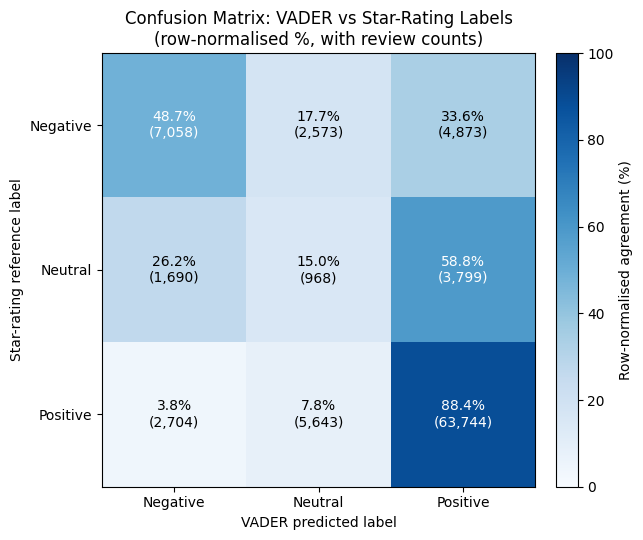

Confusion matrix figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_vader_confusion_matrix.png


In [17]:
# Step 3: Comparison of VADER labels against star ratings
# The star rating is treated as the reference label so that the accuracy of the
# lexicon baseline can be quantified before the transformer stage is introduced.
# Ratings of four or five are treated as positive, three as neutral, and one or
# two as negative.

import os
import numpy as np
import matplotlib.pyplot as plt

# A reference sentiment label is derived from the star rating
def assign_rating_label(rating):
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'neutral'

df['rating_label'] = df['rating'].apply(assign_rating_label)

# A cross-tabulation of the two labelling schemes is produced
label_order = ['negative', 'neutral', 'positive']
confusion = pd.crosstab(
    df['rating_label'], df['vader_label'],
    rownames=['Star rating'], colnames=['VADER']
).reindex(index=label_order, columns=label_order)

# A boolean series records whether the two labelling schemes agree
matches = (df['rating_label'] == df['vader_label'])

# Overall agreement is calculated as the proportion of matching labels
agreement = matches.mean()

# Agreement is also calculated within each rating class
per_class = matches.groupby(df['rating_label']).mean()

print("Cross-tabulation of star rating against VADER label:")
print(confusion)
print()
print(f"Overall agreement: {agreement:.4f} ({agreement*100:.2f}%)")
print()
print("Agreement within each rating class:")
print(per_class.round(4))

# The cross-tabulation is exported for inclusion in the results chapter
output_dir = '/content/drive/MyDrive/MSc-Project/outputs'
os.makedirs(output_dir, exist_ok=True)
confusion.to_csv(f'{output_dir}/vader_rating_crosstab.csv')
print()
print("Cross-tabulation saved to outputs directory.")

# A row-normalised version is used for the heatmap so that each rating class
# (which has a different number of reviews) is shown on a comparable 0-100% scale
confusion_pct = confusion.div(confusion.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(confusion_pct.values, cmap='Blues', vmin=0, vmax=100)

# Axis ticks and labels
ax.set_xticks(range(len(label_order)))
ax.set_yticks(range(len(label_order)))
ax.set_xticklabels([l.capitalize() for l in label_order])
ax.set_yticklabels([l.capitalize() for l in label_order])
ax.set_xlabel('VADER predicted label')
ax.set_ylabel('Star-rating reference label')
ax.set_title('Confusion Matrix: VADER vs Star-Rating Labels\n(row-normalised %, with review counts)')

# Each cell is annotated with both the percentage and the underlying review count,
# and text colour is switched to white on darker cells so it stays readable
threshold = confusion_pct.values.max() / 2
for i, rating_class in enumerate(label_order):
    for j, vader_class in enumerate(label_order):
        pct = confusion_pct.iloc[i, j]
        count = confusion.iloc[i, j]
        text_colour = 'white' if pct > threshold else 'black'
        ax.text(
            j, i, f'{pct:.1f}%\n({count:,})',
            ha='center', va='center',
            color=text_colour, fontsize=10
        )

# A colour bar shows the row-normalised percentage scale
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Row-normalised agreement (%)')

plt.tight_layout()

# The figure is saved at 300 dpi for inclusion in the dissertation
confusion_figure_path = f'{output_dir}/fig_vader_confusion_matrix.png'
plt.savefig(confusion_figure_path, dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix figure saved to:", confusion_figure_path)

## Visualisation of the VADER baseline results

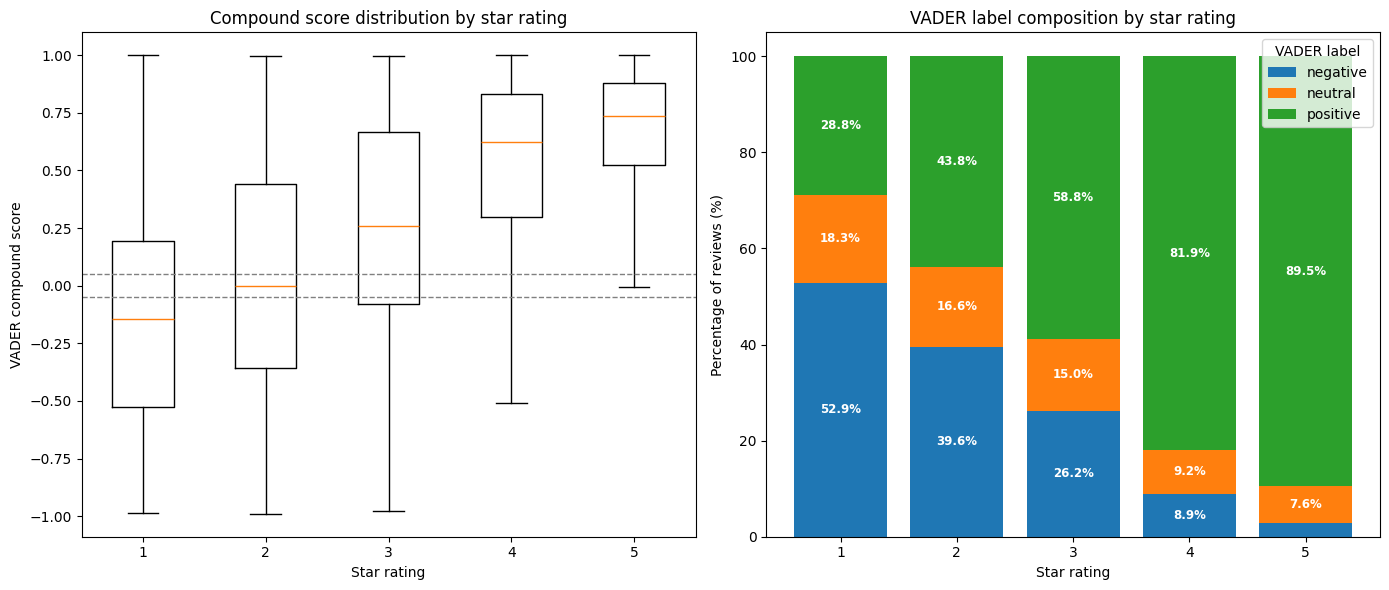

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_vader_baseline.png
Summary table saved to outputs directory.


In [18]:
# Step 4: Visualisation of the VADER baseline results
# Two panels are produced. The left panel shows the distribution of compound
# scores across the five star ratings, indicating whether the lexicon baseline
# separates the rating classes. The right panel shows the percentage of VADER
# labels assigned within each star rating, exposing the misclassification of
# low-rated reviews as positive.

import matplotlib.pyplot as plt

# A figure with two panels is created
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel one: compound score distribution by star rating
rating_groups = [df.loc[df['rating'] == r, 'vader_compound'] for r in [1, 2, 3, 4, 5]]
axes[0].boxplot(rating_groups, tick_labels=['1', '2', '3', '4', '5'], showfliers=False)
axes[0].axhline(0.05, linestyle='--', linewidth=1, color='grey')
axes[0].axhline(-0.05, linestyle='--', linewidth=1, color='grey')
axes[0].set_xlabel('Star rating')
axes[0].set_ylabel('VADER compound score')
axes[0].set_title('Compound score distribution by star rating')

# Panel two: percentage of VADER labels within each star rating
label_order = ['negative', 'neutral', 'positive']
proportions = (
    pd.crosstab(df['rating'], df['vader_label'], normalize='index')
    .reindex(columns=label_order)
)
percentages = proportions * 100

bottom = np.zeros(len(percentages))
bars = {}
for label in label_order:
    bars[label] = axes[1].bar(
        percentages.index.astype(int).astype(str),
        percentages[label],
        bottom=bottom,
        label=label
    )
    # Percentage annotation inside each segment
    for i, (value, bot) in enumerate(zip(percentages[label], bottom)):
        if value >= 5:
            axes[1].text(
                i, bot + value / 2,
                f'{value:.1f}%',
                ha='center', va='center',
                fontsize=8.5, color='white', fontweight='bold'
            )
    bottom += percentages[label].values

axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('Percentage of reviews (%)')
axes[1].set_title('VADER label composition by star rating')
axes[1].legend(title='VADER label')
axes[1].set_ylim(0, 105)

plt.tight_layout()

# The figure is saved at 300 dpi for inclusion in the dissertation
figure_path = f'{output_dir}/fig_vader_baseline.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", figure_path)

# The underlying proportions are exported as a summary table
percentages.round(2).to_csv(f'{output_dir}/vader_label_proportions_by_rating.csv')
print("Summary table saved to outputs directory.")

## Stage 2: Contextual Classification (RoBERTa)

In [19]:
# Step 5: Installation and loading of the RoBERTa sentiment model
# The transformer stage introduces contextual sentiment classification to
# address the limitations of the lexicon baseline. A RoBERTa model fine-tuned
# for sentiment classification is obtained from the HuggingFace model hub
# [Liu et al., 2019; Wolf et al., 2020]. The pre-installed PyTorch build is
# retained to preserve compatibility with the runtime's CUDA libraries.

!pip install -q transformers

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# The installed versions are recorded for reproducibility
print("PyTorch version:", torch.__version__)

# The availability of GPU acceleration is verified before proceeding
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Compute device selected:", device)
if device.type == 'cuda':
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected. The runtime type should be set to T4 GPU.")

# The pre-trained model and its tokenizer are loaded
model_name = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# The model is transferred to the selected device and set to evaluation mode
model.to(device)
model.eval()

# The label mapping defined by the model configuration is displayed
print()
print("Model loaded:", model_name)
print("Label mapping:", model.config.id2label)

PyTorch version: 2.11.0+cu128
Compute device selected: cuda
GPU: Tesla T4


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded: cardiffnlp/twitter-roberta-base-sentiment-latest
Label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}


## Contextual sentiment classification using RoBERTa

In [20]:
# Step 6: Contextual sentiment classification using RoBERTa
# Inference is performed in batches on the GPU. Reviews are truncated to 256
# tokens, which covers the substantial majority of the corpus while keeping
# memory use within the limits of the available device. Mixed precision is
# applied to reduce runtime. Partial results are written to Google Drive at
# frequent intervals so that an interrupted run can be resumed.

import time
from tqdm.auto import tqdm

# Inference parameters are defined
batch_size = 64
max_length = 256
checkpoint_every = 25
checkpoint_path = '/content/drive/MyDrive/MSc-Project/data/roberta_checkpoint.csv'
scored_path = '/content/drive/MyDrive/MSc-Project/data/reviews_scored.csv'
result_columns = ['roberta_label', 'roberta_prob_negative',
                  'roberta_prob_neutral', 'roberta_prob_positive']

# The review texts are extracted as a list for efficient batch slicing
texts = df['clean_text'].astype(str).tolist()
n_reviews = len(texts)

# Any existing checkpoint is loaded so that scoring resumes rather than restarts
if os.path.exists(checkpoint_path):
    results = pd.read_csv(checkpoint_path).values.tolist()
    start_index = len(results)
    print(f"Checkpoint found: resuming from review {start_index:,}")
else:
    results = []
    start_index = 0
    print("No checkpoint found: scoring starts from the beginning")

# The label mapping is retrieved from the model configuration
id_to_label = model.config.id2label

start_time = time.time()

for batch_number, batch_start in enumerate(
        tqdm(range(start_index, n_reviews, batch_size), desc="Scoring reviews")):

    batch_texts = texts[batch_start:batch_start + batch_size]

    # The batch is tokenised and transferred to the compute device
    encoded = tokenizer(batch_texts, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt').to(device)

    # Predictions are generated without gradient tracking
    with torch.no_grad():
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(**encoded).logits

    # Logits are converted to class probabilities
    probabilities = torch.softmax(logits.float(), dim=1).cpu().numpy()

    # The predicted label and the three class probabilities are recorded
    for row in probabilities:
        predicted_id = int(np.argmax(row))
        results.append([id_to_label[predicted_id],
                        float(row[0]), float(row[1]), float(row[2])])

    # A checkpoint is written at the defined interval
    if batch_number > 0 and batch_number % checkpoint_every == 0:
        pd.DataFrame(results, columns=result_columns).to_csv(
            checkpoint_path, index=False)

elapsed = time.time() - start_time

# The completed results are attached to the corpus and saved immediately
roberta_df = pd.DataFrame(results, columns=result_columns)
df = pd.concat([df.reset_index(drop=True), roberta_df], axis=1)
df.to_csv(scored_path, index=False)

print()
print(f"Scoring complete for {len(roberta_df):,} reviews in {elapsed/60:.1f} minutes")
print("Scored corpus saved to:", scored_path)
print()
print(df['roberta_label'].value_counts())

Checkpoint found: resuming from review 92,864


Scoring reviews:   0%|          | 0/3 [00:00<?, ?it/s]


Scoring complete for 93,052 reviews in 0.0 minutes
Scored corpus saved to: /content/drive/MyDrive/MSc-Project/data/reviews_scored.csv

roberta_label
positive    66052
negative    16785
neutral     10215
Name: count, dtype: int64


## Comparative evaluation of the lexicon and transformer stages

In [21]:
# Step 7: Comparative evaluation of the lexicon and transformer stages
# Both sentiment methods are evaluated against the star rating, which serves as
# the reference label. Overall agreement and per-class agreement are computed so
# that the improvement contributed by the transformer stage can be quantified.

# Agreement with the reference label is computed for each method
vader_matches = (df['rating_label'] == df['vader_label'])
roberta_matches = (df['rating_label'] == df['roberta_label'])

# Overall agreement is reported for both methods
print("Overall agreement with star rating:")
print(f"  VADER   : {vader_matches.mean()*100:.2f}%")
print(f"  RoBERTa : {roberta_matches.mean()*100:.2f}%")
print()

# Per-class agreement is compiled into a single comparison table
comparison = pd.DataFrame({
    'VADER': vader_matches.groupby(df['rating_label']).mean(),
    'RoBERTa': roberta_matches.groupby(df['rating_label']).mean()
})
comparison['Improvement'] = comparison['RoBERTa'] - comparison['VADER']
comparison = comparison.round(4)

print("Agreement within each rating class:")
print(comparison)
print()

# The cross-tabulation for the transformer stage is produced
roberta_confusion = pd.crosstab(
    df['rating_label'], df['roberta_label'],
    rownames=['Star rating'], colnames=['RoBERTa']
)
print("Cross-tabulation of star rating against RoBERTa label:")
print(roberta_confusion)
print()

# The extent of agreement between the two methods is quantified
model_agreement = (df['vader_label'] == df['roberta_label']).mean()
print(f"Agreement between VADER and RoBERTa: {model_agreement*100:.2f}%")
print()

# Both tables are exported for inclusion in the results chapter
comparison.to_csv(f'{output_dir}/sentiment_method_comparison.csv')
roberta_confusion.to_csv(f'{output_dir}/roberta_rating_crosstab.csv')
print("Comparison tables saved to outputs directory.")

Overall agreement with star rating:
  VADER   : 77.13%
  RoBERTa : 82.21%

Agreement within each rating class:
               VADER  RoBERTa  Improvement
rating_label                              
negative      0.4866   0.7868       0.3002
neutral       0.1499   0.2616       0.1117
positive      0.8842   0.8794      -0.0048

Cross-tabulation of star rating against RoBERTa label:
RoBERTa      negative  neutral  positive
Star rating                             
negative        11412     2155       937
neutral          3051     1689      1717
positive         2322     6371     63398

Agreement between VADER and RoBERTa: 80.29%

Comparison tables saved to outputs directory.


## Visualisation of the comparative sentiment results

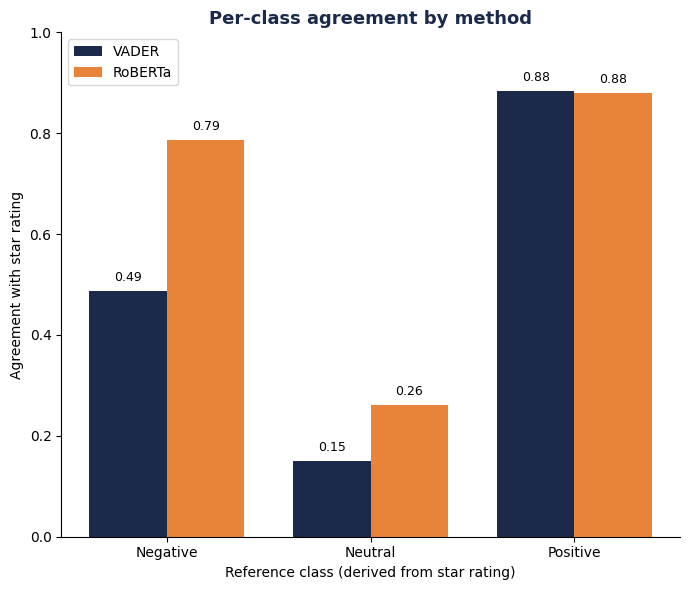

Figure 1 saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_sentiment_agreement_by_class.png


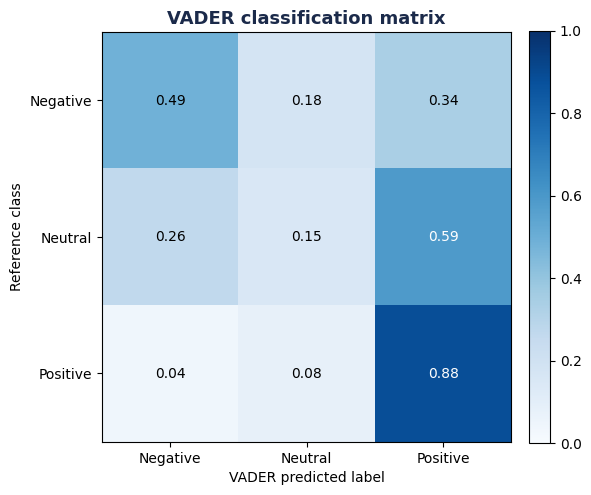

Figure 2 saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_vader_classification_matrix.png


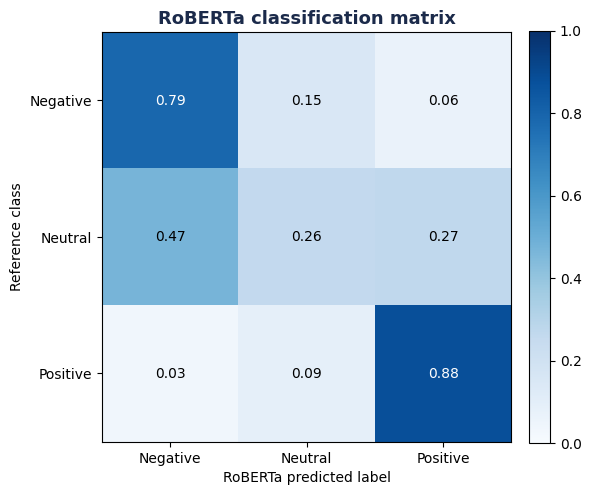

Figure 3 saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_roberta_classification_matrix.png


In [22]:
# Step 8 (revised): Visualisation of the comparative sentiment results —
# produced as three separate figures instead of one combined panel, so
# each can be referenced and captioned individually in the dissertation.

class_order = ['negative', 'neutral', 'positive']
x_positions = np.arange(len(class_order))
bar_width = 0.38

# ── Figure 1: Per-class agreement — VADER vs RoBERTa ──────────────────
fig1, ax1 = plt.subplots(figsize=(7, 6))

ax1.bar(x_positions - bar_width/2,
        comparison.loc[class_order, 'VADER'],
        width=bar_width, label='VADER', color='#1B2A4A')
ax1.bar(x_positions + bar_width/2,
        comparison.loc[class_order, 'RoBERTa'],
        width=bar_width, label='RoBERTa', color='#E8833A')
ax1.set_xticks(x_positions)
ax1.set_xticklabels([c.capitalize() for c in class_order])
ax1.set_xlabel('Reference class (derived from star rating)')
ax1.set_ylabel('Agreement with star rating')
ax1.set_title('Per-class agreement by method', fontsize=13,
              fontweight='bold', color='#1B2A4A')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for position, class_name in zip(x_positions, class_order):
    ax1.text(position - bar_width/2, comparison.loc[class_name, 'VADER'] + 0.02,
              f"{comparison.loc[class_name, 'VADER']:.2f}",
              ha='center', fontsize=9)
    ax1.text(position + bar_width/2, comparison.loc[class_name, 'RoBERTa'] + 0.02,
              f"{comparison.loc[class_name, 'RoBERTa']:.2f}",
              ha='center', fontsize=9)

plt.tight_layout()
agreement_fig_path = f'{output_dir}/fig_sentiment_agreement_by_class.png'
plt.savefig(agreement_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure 1 saved to:", agreement_fig_path)

# ── Figure 2: VADER classification matrix ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 5.5))

vader_normalised = confusion.reindex(index=class_order, columns=class_order)
vader_normalised = vader_normalised.div(vader_normalised.sum(axis=1), axis=0)

image2 = ax2.imshow(vader_normalised.values, cmap='Blues', vmin=0, vmax=1)
ax2.set_xticks(range(len(class_order)))
ax2.set_yticks(range(len(class_order)))
ax2.set_xticklabels([c.capitalize() for c in class_order])
ax2.set_yticklabels([c.capitalize() for c in class_order])
ax2.set_xlabel('VADER predicted label')
ax2.set_ylabel('Reference class')
ax2.set_title('VADER classification matrix', fontsize=13,
              fontweight='bold', color='#1B2A4A')

for row in range(len(class_order)):
    for column in range(len(class_order)):
        value = vader_normalised.values[row, column]
        ax2.text(column, row, f"{value:.2f}", ha='center', va='center',
                 color='white' if value > 0.5 else 'black', fontsize=10)

fig2.colorbar(image2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
vader_matrix_path = f'{output_dir}/fig_vader_classification_matrix.png'
plt.savefig(vader_matrix_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure 2 saved to:", vader_matrix_path)

# ── Figure 3: RoBERTa classification matrix ────────────────────────────
fig3, ax3 = plt.subplots(figsize=(6, 5.5))

roberta_normalised = roberta_confusion.reindex(index=class_order, columns=class_order)
roberta_normalised = roberta_normalised.div(roberta_normalised.sum(axis=1), axis=0)

image3 = ax3.imshow(roberta_normalised.values, cmap='Blues', vmin=0, vmax=1)
ax3.set_xticks(range(len(class_order)))
ax3.set_yticks(range(len(class_order)))
ax3.set_xticklabels([c.capitalize() for c in class_order])
ax3.set_yticklabels([c.capitalize() for c in class_order])
ax3.set_xlabel('RoBERTa predicted label')
ax3.set_ylabel('Reference class')
ax3.set_title('RoBERTa classification matrix', fontsize=13,
              fontweight='bold', color='#1B2A4A')

for row in range(len(class_order)):
    for column in range(len(class_order)):
        value = roberta_normalised.values[row, column]
        ax3.text(column, row, f"{value:.2f}", ha='center', va='center',
                 color='white' if value > 0.5 else 'black', fontsize=10)

fig3.colorbar(image3, ax=ax3, fraction=0.046, pad=0.04)
plt.tight_layout()
roberta_matrix_path = f'{output_dir}/fig_roberta_classification_matrix.png'
plt.savefig(roberta_matrix_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3 saved to:", roberta_matrix_path)

## Stage 3: Aspect-based Sentiment Analysis

In [23]:
# Step 9: Loading of the aspect-based sentiment model
# Aspect-based sentiment analysis is introduced so that sentiment can be
# attributed to specific product attributes rather than to the review as a
# whole. The aspect sentiment model developed within the PyABSA framework
# [Yang and Li, 2023] is loaded directly through the HuggingFace interface,
# as the packaged distribution presented unresolved dependency conflicts
# within the runtime environment.

from transformers import AutoTokenizer

# The compute device is confirmed before the model is loaded
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Compute device selected:", device)
if device.type == 'cuda':
    print("GPU:", torch.cuda.get_device_name(0))

# The tokenizer for the aspect sentiment model is loaded
aspect_model_name = 'yangheng/deberta-v3-base-absa-v1.1'
aspect_tokenizer = AutoTokenizer.from_pretrained(aspect_model_name)

print()
print("Tokenizer loaded:", aspect_model_name)

Compute device selected: cuda
GPU: Tesla T4

Tokenizer loaded: yangheng/deberta-v3-base-absa-v1.1


## Loading of the aspect sentiment classification model

In [24]:
# Step 10: Loading of the aspect sentiment classification model
# The model assigns a sentiment polarity to a specified aspect within a given
# sentence, forming the classification component of the aspect-based stage
# [Yang and Li, 2023].

from transformers import AutoModelForSequenceClassification

# The aspect sentiment classifier is loaded
aspect_model = AutoModelForSequenceClassification.from_pretrained(aspect_model_name)

# The model is transferred to the selected device and set to evaluation mode
aspect_model.to(device)
aspect_model.eval()

# The label mapping defined by the model configuration is displayed
print("Model loaded:", aspect_model_name)
print("Label mapping:", aspect_model.config.id2label)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Model loaded: yangheng/deberta-v3-base-absa-v1.1
Label mapping: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}


## Definition of the aspect lexicon

In [25]:
# Step 11: Definition of the aspect lexicon
# Aspect-based analysis requires a fixed set of attributes so that sentiment
# remains comparable across niches. Eleven product attributes relevant to the
# Home and Kitchen category are defined, each represented by a set of surface
# forms observed in review text. The lexicon was developed iteratively: an
# initial specification was assessed for coverage against the corpus, and
# reviews in which no aspect was detected were sampled to identify recurring
# attributes that had been omitted. This procedure identified comfort, odour,
# functional performance and noise as substantive attributes absent from the
# initial specification. Delivery and other service attributes are excluded,
# as they reflect seller logistics rather than product characteristics and
# would not transfer to a prospective market entrant.

aspect_lexicon = {
    'quality': ['quality', 'well made', 'made well', 'well-made', 'cheap',
                'cheaply', 'flimsy', 'sturdy', 'solid', 'construction',
                'material', 'materials', 'build', 'built', 'workmanship',
                'gauge', 'thin', 'thick', 'heavy duty', 'heavy-duty'],
    'performance': ['works', 'work', 'worked', 'working', 'function',
                    'functions', 'functional', 'performance', 'performs',
                    'effective', 'efficient', 'powerful', 'power', 'strong',
                    'weak', 'suction', 'stopped working', 'does not work',
                    'doesn t work', 'defective', 'faulty', 'error',
                    'malfunction', 'unreliable', 'reliable', 'consistent',
                    'inconsistent', 'evenly', 'uneven', 'settings',
                    'temperature', 'heat', 'heats', 'speed', 'battery',
                    'charge', 'charging'],
    'price': ['price', 'priced', 'cost', 'costs', 'value', 'worth',
              'expensive', 'affordable', 'money', 'bargain', 'overpriced',
              'pricey', 'cheaper', 'deal'],
    'durability': ['durable', 'durability', 'lasted', 'lasts', 'broke',
                   'broken', 'break', 'breaks', 'cracked', 'crack',
                   'wore out', 'worn out', 'rusted', 'rust', 'leaked',
                   'leaks', 'leaking', 'damaged', 'damage', 'tore', 'torn',
                   'ripped', 'fell apart', 'warped', 'bent', 'chipped',
                   'peeling', 'faded'],
    'size': ['size', 'sized', 'dimensions', 'too small', 'too big',
             'too large', 'fits', 'fit', 'compact', 'bulky', 'capacity',
             'height', 'width', 'length', 'narrow', 'wide', 'tall',
             'roomy', 'spacious', 'lightweight', 'heavy', 'weight'],
    'ease_of_use': ['easy to use', 'easy', 'simple', 'difficult',
                    'complicated', 'assembly', 'assemble', 'instructions',
                    'user friendly', 'user-friendly', 'intuitive',
                    'convenient', 'straightforward', 'hassle', 'setup',
                    'set up', 'install', 'installation'],
    'cleaning': ['clean', 'cleaning', 'wash', 'washing', 'dishwasher',
                 'easy to clean', 'hard to clean', 'stains', 'staining',
                 'residue', 'wipe', 'rinse', 'scrub', 'washable'],
    'appearance': ['look', 'looks', 'looking', 'design', 'style',
                   'stylish', 'colour', 'color', 'attractive', 'beautiful',
                   'ugly', 'appearance', 'aesthetic', 'finish', 'gorgeous',
                   'pretty', 'elegant', 'modern', 'matches', 'match',
                   'picture', 'photo'],
    'comfort': ['comfortable', 'comfort', 'uncomfortable', 'soft', 'softest',
                'softness', 'firm', 'hard', 'plush', 'cushioned', 'padding',
                'texture', 'smooth', 'rough', 'scratchy', 'cozy', 'luxurious',
                'silky'],
    'smell': ['smell', 'smells', 'smelled', 'odor', 'odour', 'odors',
              'fragrance', 'scent', 'stink', 'stinks', 'chemical smell',
              'fumes', 'aroma'],
    'noise': ['noise', 'noisy', 'noisey', 'loud', 'quiet', 'silent',
              'sound', 'sounds', 'rattle', 'rattles', 'buzzing', 'humming',
              'vibration']
}

# The composition of the lexicon is reported
print("Aspects defined:", len(aspect_lexicon))
print()

for aspect_name, surface_forms in aspect_lexicon.items():
    print(" ", aspect_name.ljust(14), len(surface_forms), "surface forms")

print()
print("Total surface forms:", sum(len(v) for v in aspect_lexicon.values()))

Aspects defined: 11

  quality        20 surface forms
  performance    37 surface forms
  price          14 surface forms
  durability     28 surface forms
  size           22 surface forms
  ease_of_use    18 surface forms
  cleaning       14 surface forms
  appearance     22 surface forms
  comfort        18 surface forms
  smell          13 surface forms
  noise          13 surface forms

Total surface forms: 219


## Lexicon validation on a small sample

In [26]:
# Step 12: Definition and verification of the aspect matching procedure
# The lexicon is applied to a small sample so that the behaviour of the
# matching procedure can be inspected before the full corpus is processed.

import re

def find_aspects(review_text, lexicon):
    """Returns the aspects whose surface forms appear in the review text."""
    text_lower = str(review_text).lower()
    found = []
    for aspect_name, surface_forms in lexicon.items():
        for form in surface_forms:
            if re.search(r'\b' + re.escape(form) + r'\b', text_lower):
                found.append(aspect_name)
                break
    return found

# A small reproducible sample is drawn for inspection
sample = df.sample(5, random_state=42)

for position, (_, review) in enumerate(sample.iterrows(), start=1):
    text = str(review['clean_text'])
    print(f"--- Review {position} | rating: {review['rating']} ---")
    print(text[:300])
    print("Aspects found:", find_aspects(text, aspect_lexicon))
    print()

--- Review 1 | rating: 5.0 ---
Loved the tree. Perfect fit for the space I put it in. Grandchildren loved the lights. I didn’t feel it was too bright like some other reviews
Aspects found: ['size']

--- Review 2 | rating: 1.0 ---
Cheap, you get what you pay for. I usually get these microfiber sheets, so know how soft and silky they can feel. These are non of those. Don’t waste your money.
Aspects found: ['quality', 'price', 'comfort']

--- Review 3 | rating: 2.0 ---
The pockets on the sides are innovative and useful. But individual shelves are only reinforced to hold their shape horizontally on the front, not on the sides or back of individual shelves, so it isn't quite as sturdy as I was hoping it would be. The flap hanging off the top shelf also seems to serv
Aspects found: ['quality']

--- Review 4 | rating: 5.0 ---
Love It, makes great toast and bagels. The red is perfect in my kitchen.
Aspects found: []

--- Review 5 | rating: 4.0 ---
Love how dark they are and how easy they are t

## Stage 3b: Aspect Lexicon Justification — Word Analysis

In [27]:
# Step 12b: Word frequency and TF-IDF analysis for lexicon justification
# The most frequently occurring words within each aspect-matched review set
# are identified to provide empirical justification for the surface forms
# selected in the aspect lexicon.

!pip install -q wordcloud

import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Aspect detection across the full corpus (missing piece, added) ────
# Produces all_matches — a list of aspect lists, one per review,
# aligned with df.index — required by the grouping step below.
print("Detecting aspects across the full corpus...")
all_matches = df['clean_text'].apply(
    lambda text: find_aspects(text, aspect_lexicon)
)

detected_count = sum(1 for m in all_matches if len(m) > 0)
print(f"Reviews processed        : {len(all_matches):,}")
print(f"Reviews with ≥1 aspect   : {detected_count:,}  ({detected_count/len(all_matches)*100:.1f}%)")
print(f"Reviews with no aspect   : {len(all_matches)-detected_count:,}  ({(len(all_matches)-detected_count)/len(all_matches)*100:.1f}%)")
print()

# A set of common English stop words is defined to remove uninformative words
stop_words = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'it', 'is', 'was', 'are', 'be', 'been', 'have', 'has',
    'had', 'do', 'did', 'not', 'this', 'that', 'i', 'my', 'me', 'we',
    'they', 'them', 'so', 'if', 'as', 'by', 'its', 'just', 'very', 'too',
    'also', 'would', 'could', 'get', 'got', 'one', 'use', 'used', 'like',
    'will', 'can', 'all', 'more', 'than', 'when', 'what', 'which', 'there',
    'their', 'our', 'your', 'about', 'up', 'out', 'from', 'product', 'item', 'you', 'your', 'these', 'those', 'were', 'put', 'off', 'because',
'only', 'don', 'does', 'after', 'really', 'little', 'much', 'back',
'first', 'even', 'bought', 'love', 'great', 'good', 'nice', 'well',
'lot', 'far', 'yet', 'still', 'while', 'since', 'then', 'now',
'how', 'being', 're', 'didn', 'wasn', 'isn', 'aren', 'couldn',
'won', 'time', 'never', 'always', 'make', 'made', 'buy', 'purchased'
}

# Reviews are grouped by detected aspect
aspect_review_texts = {}
for row_index, detected in zip(df.index, all_matches):
    text = str(df.loc[row_index, 'clean_text']).lower()
    for aspect in detected:
        if aspect not in aspect_review_texts:
            aspect_review_texts[aspect] = []
        aspect_review_texts[aspect].append(text)

print("Aspect groups prepared:")
for aspect, texts in aspect_review_texts.items():
    print(f"  {aspect:<14} {len(texts):>6,} reviews")

Detecting aspects across the full corpus...
Reviews processed        : 93,052
Reviews with ≥1 aspect   : 66,269  (71.2%)
Reviews with no aspect   : 26,783  (28.8%)

Aspect groups prepared:
  ease_of_use    13,999 reviews
  appearance     21,967 reviews
  quality        18,310 reviews
  price          11,961 reviews
  size           14,875 reviews
  smell           1,771 reviews
  performance    17,139 reviews
  cleaning        6,862 reviews
  durability      7,273 reviews
  comfort         8,217 reviews
  noise           1,725 reviews


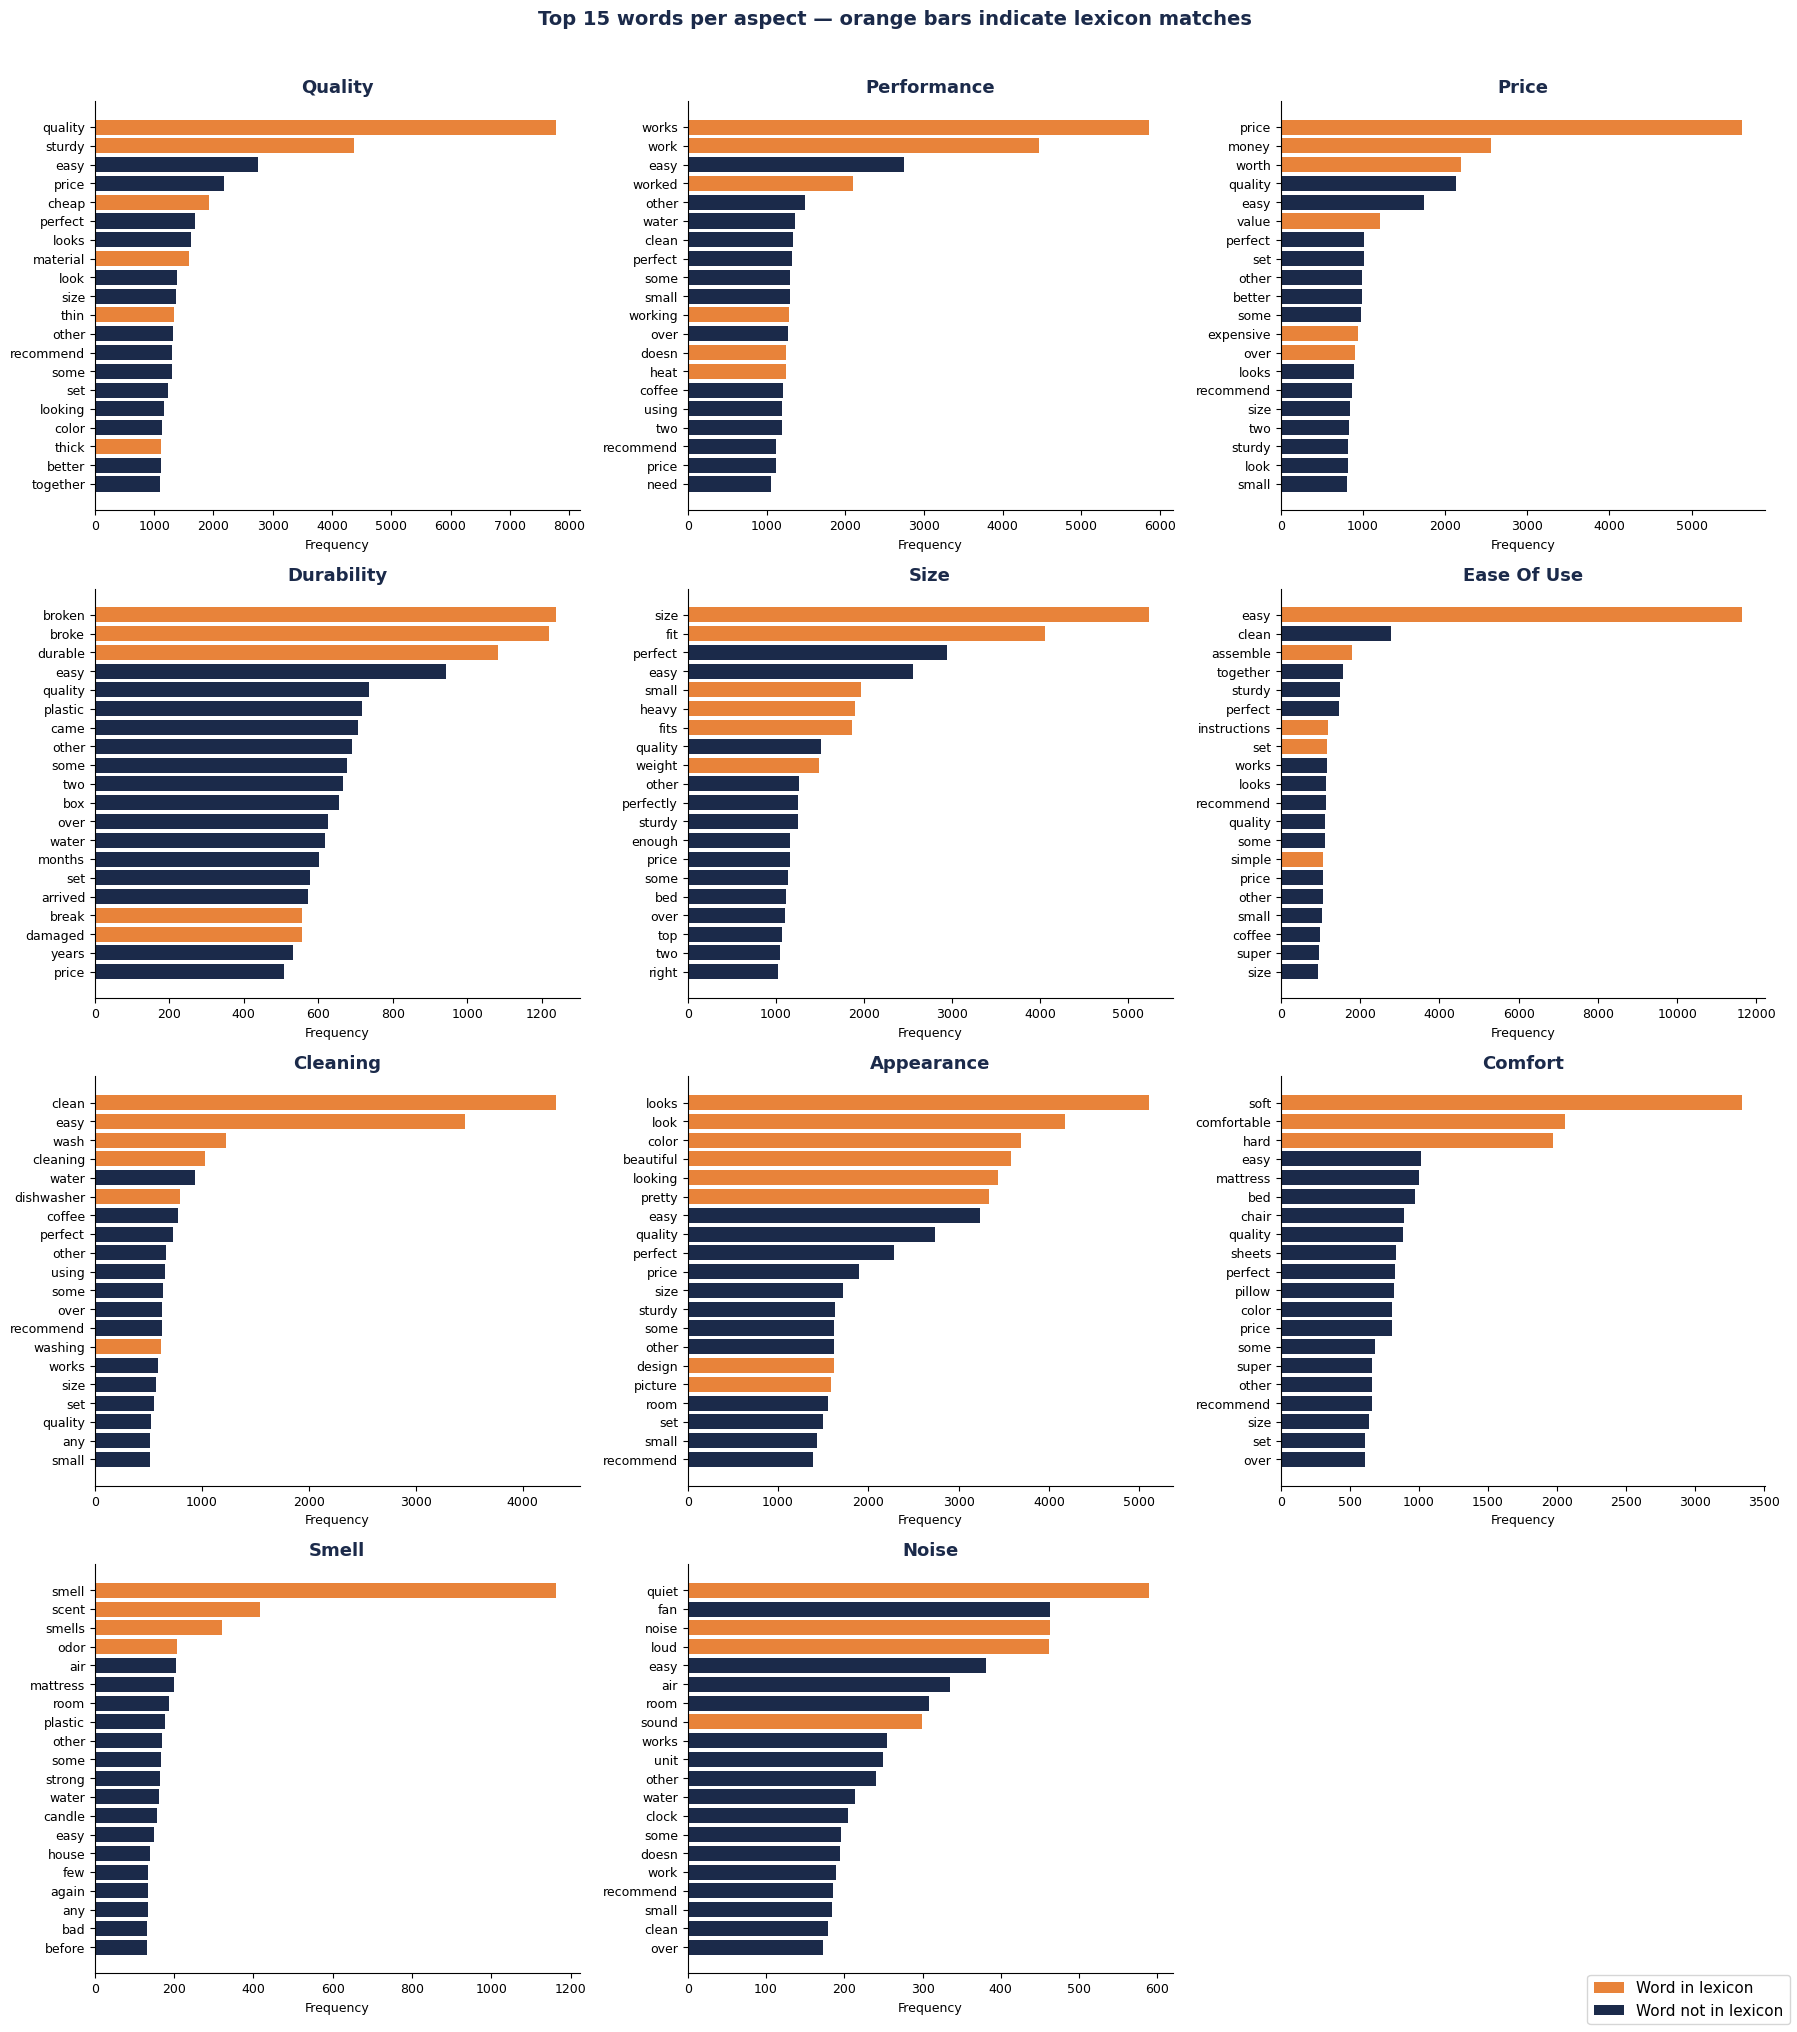

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_aspect_word_frequency.png


In [28]:
# Step 12c: Word frequency analysis per aspect
# The 20 most frequent words within each aspect-matched review set are
# identified and visualised. High-frequency words that align with the
# lexicon surface forms confirm that the chosen terms reflect genuine
# usage patterns in the corpus.

def get_top_words(texts, top_n=20):
    all_words = []
    for text in texts:
        words = re.findall(r'\b[a-z]{3,}\b', text)
        all_words.extend([w for w in words if w not in stop_words])
    return Counter(all_words).most_common(top_n)

# A 4x3 grid of bar charts is produced, one per aspect
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

aspect_order = ['quality', 'performance', 'price', 'durability', 'size',
                'ease_of_use', 'cleaning', 'appearance', 'comfort',
                'smell', 'noise']

for i, aspect in enumerate(aspect_order):
    texts = aspect_review_texts[aspect]
    top_words = get_top_words(texts)
    words = [w for w, _ in top_words]
    counts = [c for _, c in top_words]

    # Lexicon words are highlighted in orange, others in navy
    lexicon_words = set(aspect_lexicon[aspect])
    colors = ['#E8833A' if any(w in lw or lw in w
              for lw in lexicon_words) else '#1B2A4A'
              for w in words]

    axes[i].barh(words[::-1], counts[::-1], color=colors[::-1])
    axes[i].set_title(aspect.replace('_', ' ').title(), fontsize=13,
                      fontweight='bold', color='#1B2A4A')
    axes[i].set_xlabel('Frequency', fontsize=9)
    axes[i].tick_params(labelsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# The last (empty) panel is hidden
axes[-1].set_visible(False)

# A legend is added to explain the colour coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E8833A', label='Word in lexicon'),
    Patch(facecolor='#1B2A4A', label='Word not in lexicon')
]
fig.legend(handles=legend_elements, loc='lower right',
           fontsize=11, frameon=True)

plt.suptitle('Top 15 words per aspect — orange bars indicate lexicon matches',
             fontsize=14, fontweight='bold', color='#1B2A4A', y=1.01)
plt.tight_layout()

freq_path = f'{output_dir}/fig_aspect_word_frequency.png'
plt.savefig(freq_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", freq_path)

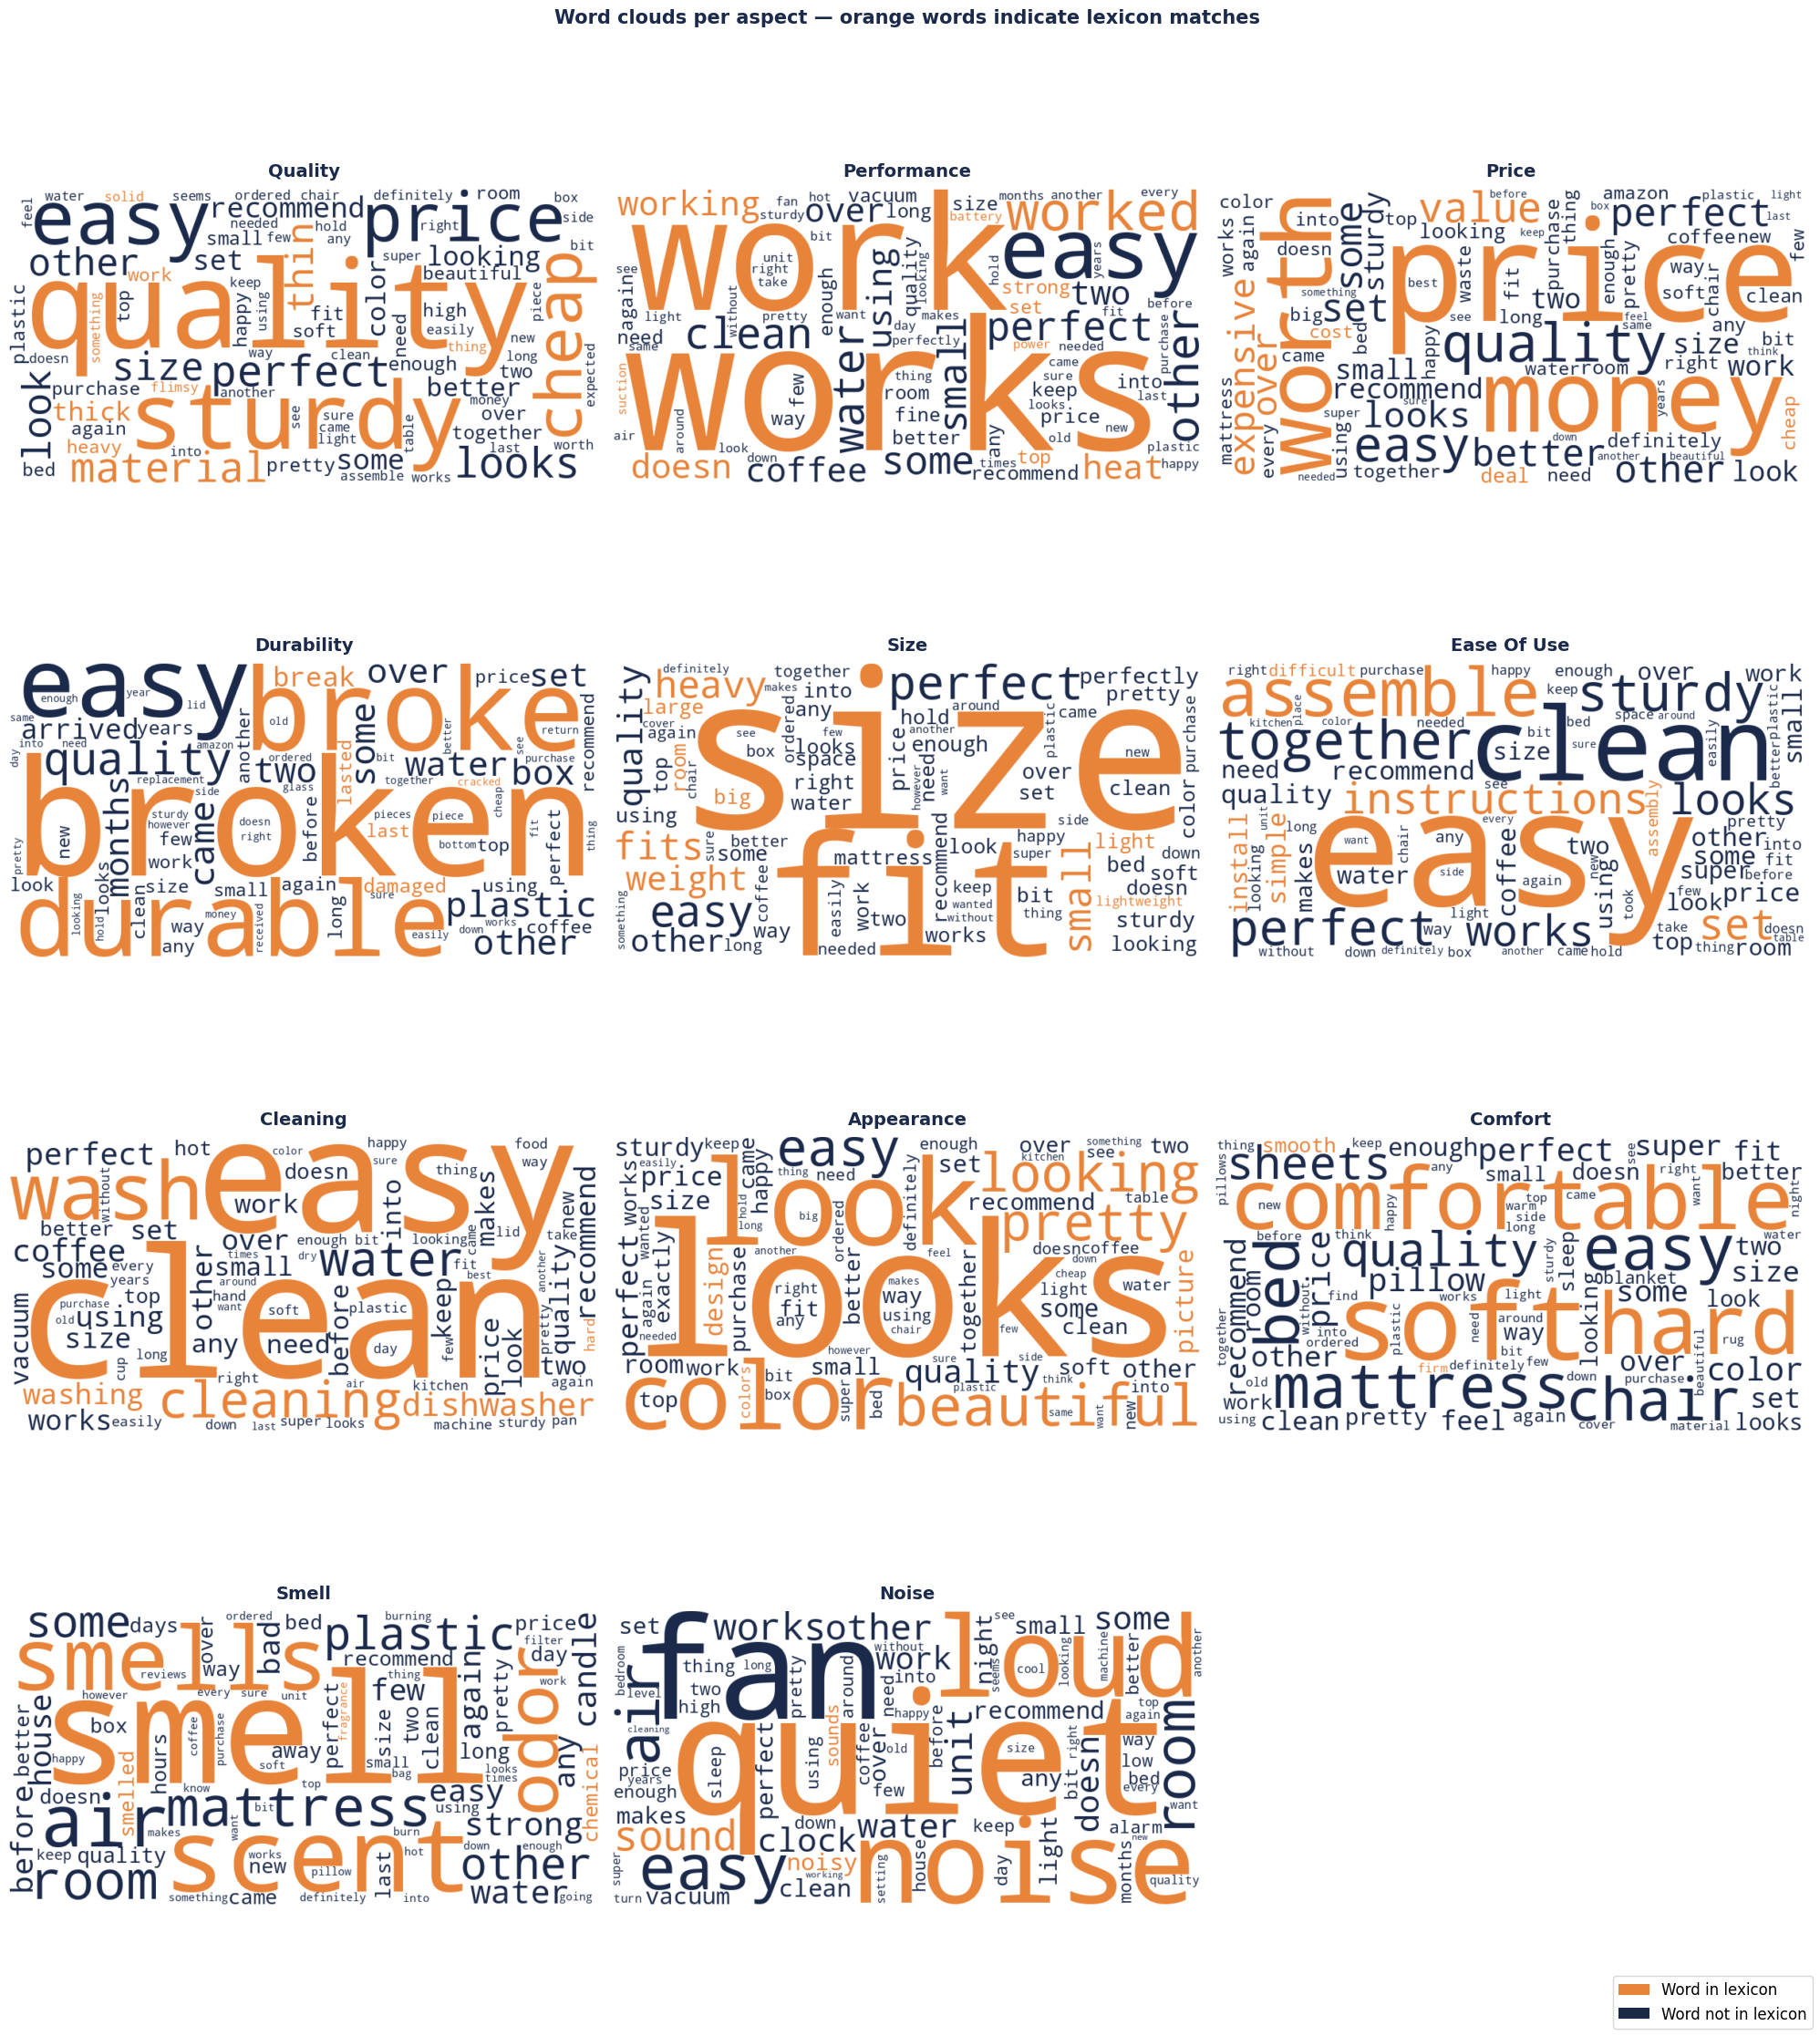

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_aspect_word_clouds.png


In [29]:
# Step 12d: Word cloud visualisation per aspect
# A word cloud is generated for each aspect using the reviews in which that
# aspect was detected. Larger words appear more frequently in the corpus.
# Words present in the aspect lexicon are highlighted in orange to confirm
# that the chosen surface forms reflect genuine usage patterns.

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_word_frequencies(texts):
    word_freq = Counter()
    for text in texts:
        words = re.findall(r'\b[a-z]{3,}\b', text)
        word_freq.update([w for w in words if w not in stop_words])
    return dict(word_freq)

def orange_grey_colourfunc(aspect):
    lexicon_words = set(aspect_lexicon[aspect])
    def colour_func(word, **kwargs):
        if any(word in lw or lw in word for lw in lexicon_words):
            return '#E8833A'
        return '#1B2A4A'
    return colour_func

aspect_order = ['quality', 'performance', 'price', 'durability', 'size',
                'ease_of_use', 'cleaning', 'appearance', 'comfort',
                'smell', 'noise']

fig, axes = plt.subplots(4, 3, figsize=(20, 22))
axes = axes.flatten()

for i, aspect in enumerate(aspect_order):
    texts = aspect_review_texts[aspect]
    word_freq = get_word_frequencies(texts)

    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        max_words=80,
        color_func=orange_grey_colourfunc(aspect),
        prefer_horizontal=0.85,
        collocations=False
    ).generate_from_frequencies(word_freq)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(aspect.replace('_', ' ').title(),
                      fontsize=14, fontweight='bold', color='#1B2A4A', pad=10)

axes[-1].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E8833A', label='Word in lexicon'),
    Patch(facecolor='#1B2A4A', label='Word not in lexicon')
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=12, frameon=True)

plt.suptitle('Word clouds per aspect — orange words indicate lexicon matches',
             fontsize=15, fontweight='bold', color='#1B2A4A', y=1.01)
plt.tight_layout()

wc_path = f'{output_dir}/fig_aspect_word_clouds.png'
plt.savefig(wc_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", wc_path)

Vocabulary size: 3000

Noise — top TF-IDF terms:
  quiet           0.2884  [LEXICON]
  noise           0.2263  [LEXICON]
  fan             0.2263  
  loud            0.2253  [LEXICON]
  easy            0.1862  
  air             0.1638  
  room            0.1506  
  sound           0.1462  [LEXICON]
  works           0.1242  
  unit            0.1217  
  other           0.1173  
  water           0.1046  
  clock           0.1002  
  some            0.0958  
  doesn           0.0948  

Smell — top TF-IDF terms:
  smell           0.6264  [LEXICON]
  scent           0.2239  [LEXICON]
  smells          0.1722  [LEXICON]
  odor            0.1119  [LEXICON]
  air             0.1103  
  mattress        0.1076  
  room            0.1001  
  plastic         0.0958  
  other           0.0909  
  some            0.0904  
  strong          0.0883  
  water           0.0877  
  candle          0.0845  
  easy            0.0796  
  house           0.0748  



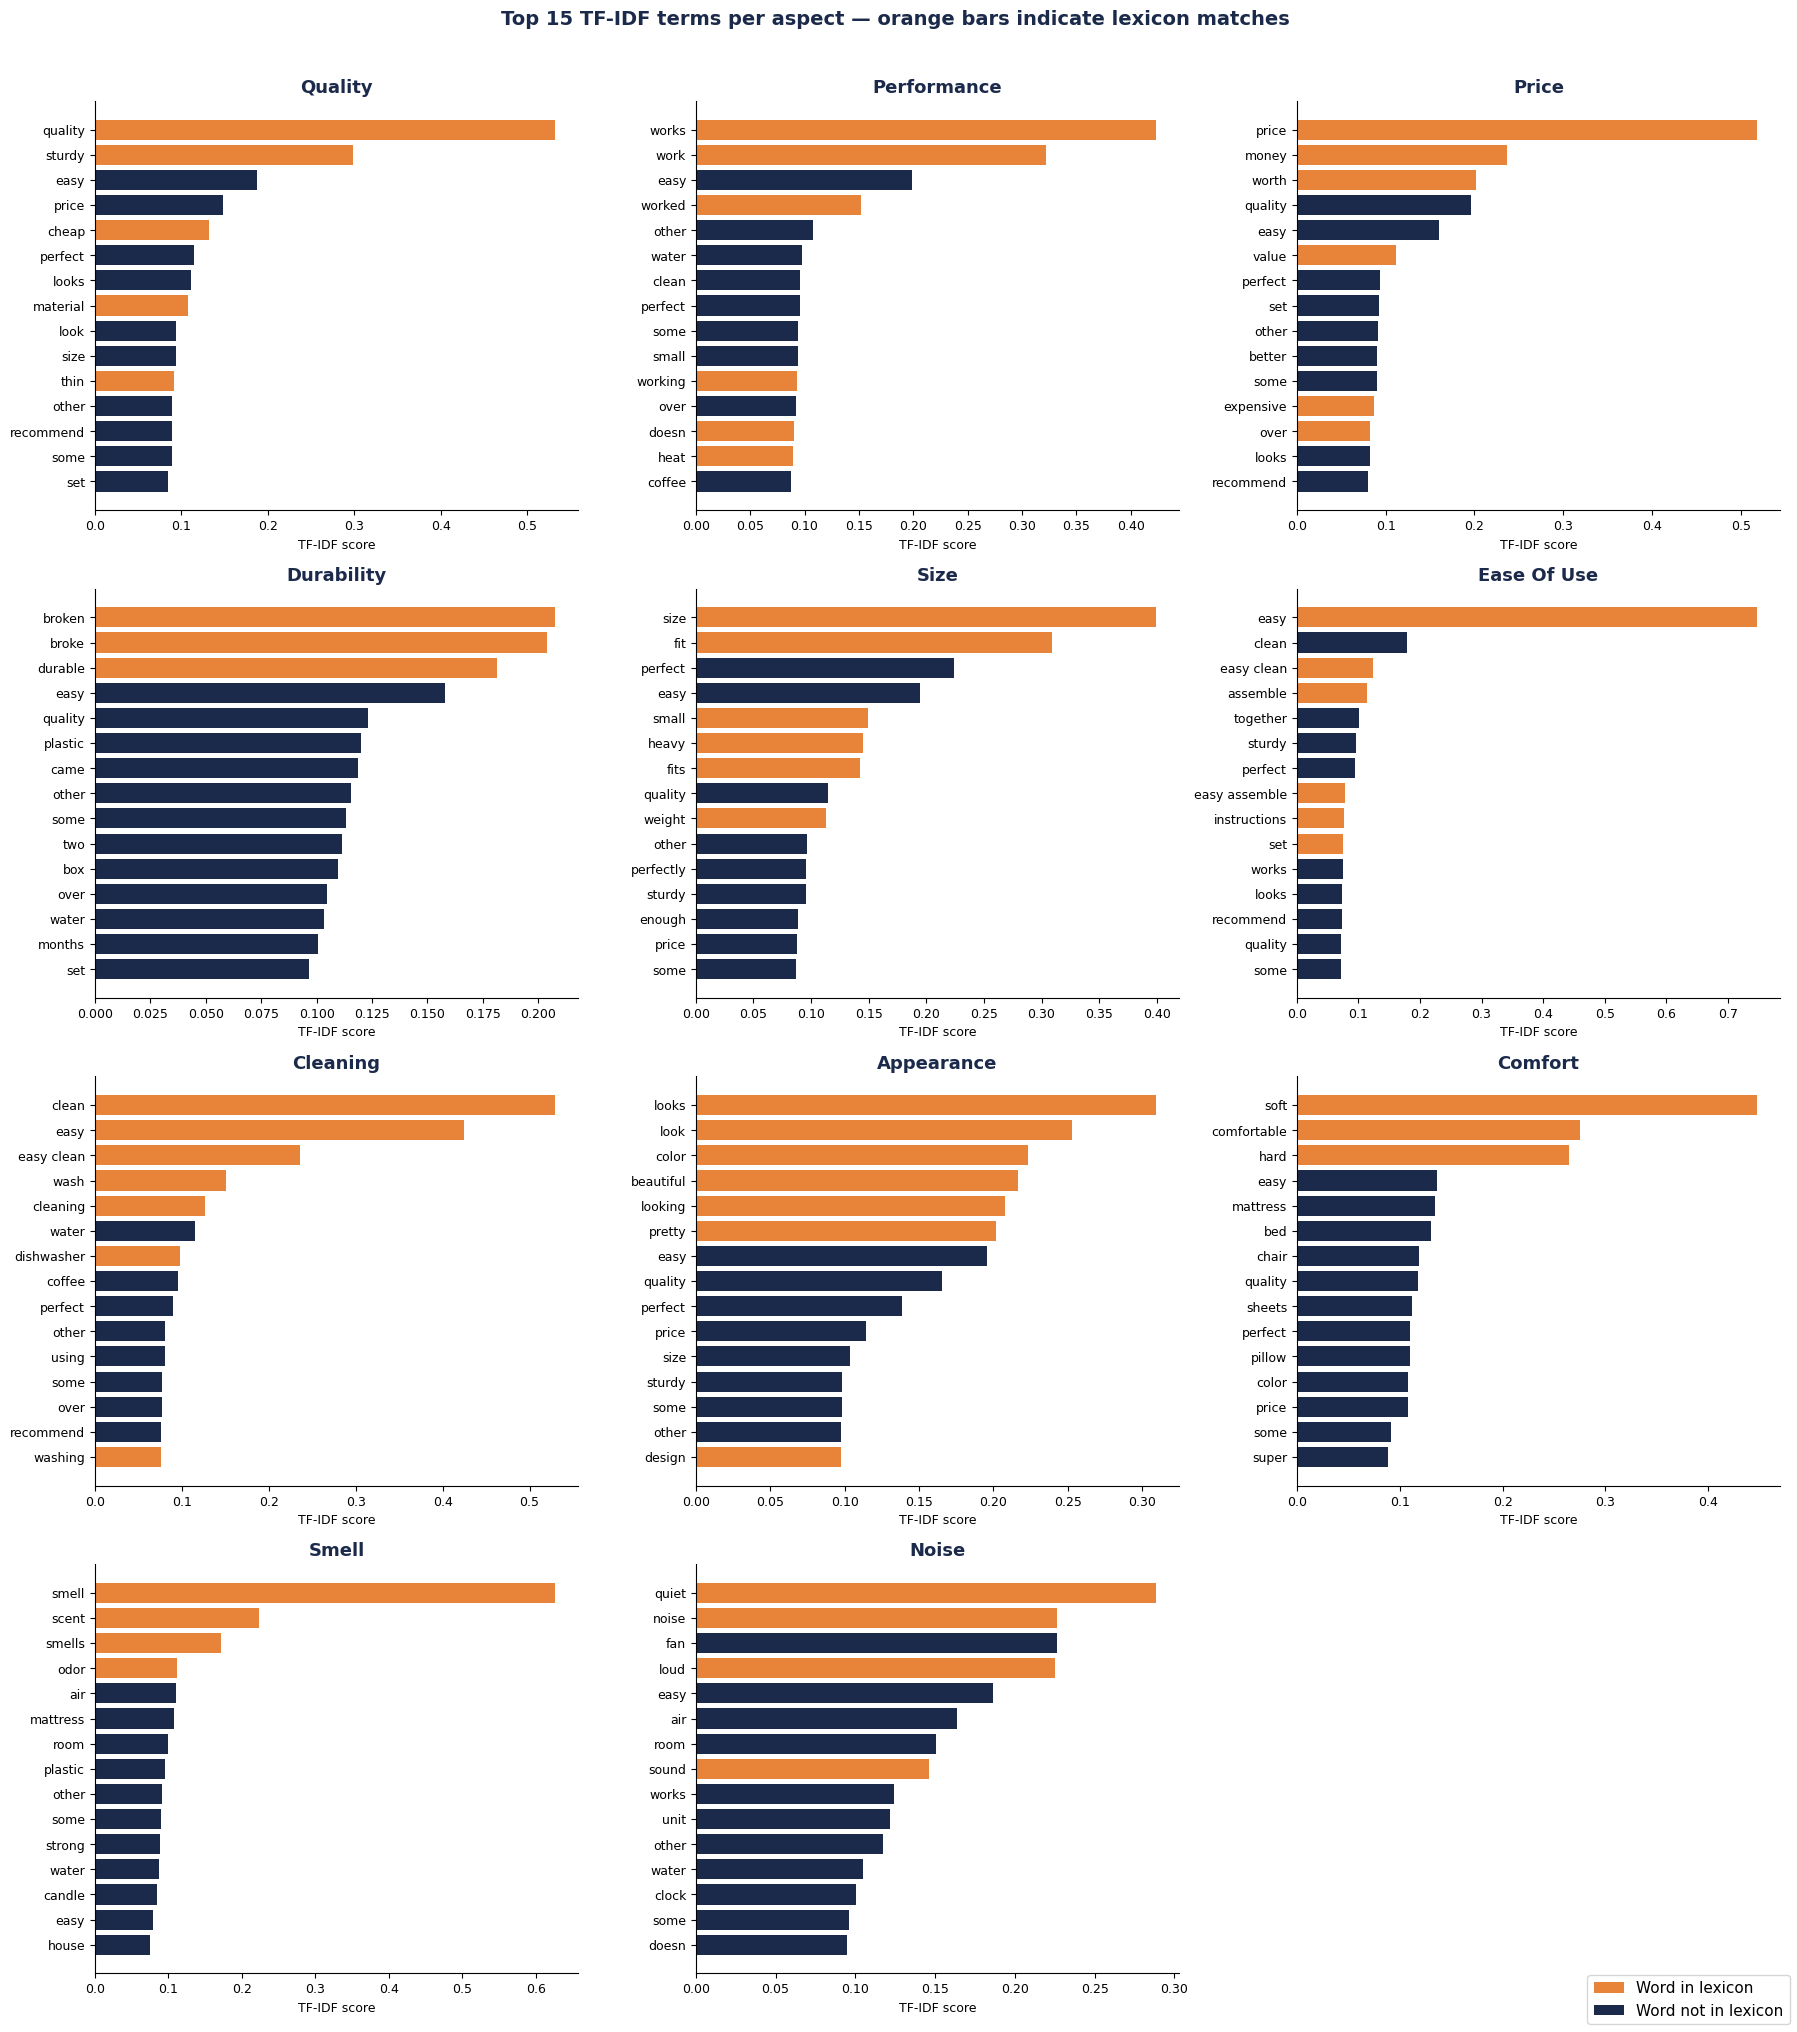

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_aspect_tfidf.png
TF-IDF table saved to outputs directory.


In [30]:
# Step 12e (corrected): TF-IDF analysis for aspect lexicon justification
# TF-IDF identifies words that are uniquely important to each aspect
# compared to all other aspects. A high TF-IDF score confirms that a word
# is not just frequent within an aspect but also distinctive to it,
# providing stronger justification for lexicon word selection than
# frequency analysis alone.
#
# CORRECTION: the original max_features=200 capped the vocabulary shared
# across all 11 aspect-documents by raw corpus-wide frequency. Because
# aspect group sizes vary substantially (Noise: 1,725 reviews; Appearance:
# 21,967 reviews), this systematically excluded distinctive vocabulary
# belonging to smaller aspects (e.g. "quiet", "loud" for Noise; "scent",
# "odor" for Smell) before TF-IDF scores were even computed. max_features
# is raised to 3000 to give smaller aspect groups a fair chance to
# contribute their distinctive terms.

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

aspect_order = ['quality', 'performance', 'price', 'durability', 'size',
                'ease_of_use', 'cleaning', 'appearance', 'comfort',
                'smell', 'noise']

aspect_documents = []
for aspect in aspect_order:
    texts = aspect_review_texts[aspect]
    cleaned_words = []
    for text in texts:
        words = re.findall(r'\b[a-z]{3,}\b', text)
        cleaned_words.extend([w for w in words if w not in stop_words])
    aspect_documents.append(' '.join(cleaned_words))

# max_features raised from 200 to 3000 — see correction note above
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(aspect_documents)
feature_names = vectorizer.get_feature_names_out()

top_n = 15
tfidf_results = {}
for i, aspect in enumerate(aspect_order):
    scores = tfidf_matrix[i].toarray().flatten()
    top_indices = scores.argsort()[::-1][:top_n]
    tfidf_results[aspect] = [
        (feature_names[j], scores[j]) for j in top_indices
    ]

# Sanity check: confirm Noise and Smell now surface their lexicon terms
print("Vocabulary size:", len(feature_names))
print()
for check_aspect in ['noise', 'smell']:
    print(f"{check_aspect.capitalize()} — top TF-IDF terms:")
    for word, score in tfidf_results[check_aspect]:
        in_lex = any(word in lw or lw in word for lw in aspect_lexicon[check_aspect])
        print(f"  {word:<15} {score:.4f}  {'[LEXICON]' if in_lex else ''}")
    print()

# A 4x3 grid of horizontal bar charts is produced
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, aspect in enumerate(aspect_order):
    words  = [w for w, _ in tfidf_results[aspect]]
    scores = [s for _, s in tfidf_results[aspect]]

    lexicon_words = set(aspect_lexicon[aspect])
    colors = ['#E8833A' if any(w in lw or lw in w
              for lw in lexicon_words) else '#1B2A4A'
              for w in words]

    axes[i].barh(words[::-1], scores[::-1], color=colors[::-1])
    axes[i].set_title(aspect.replace('_', ' ').title(),
                      fontsize=13, fontweight='bold', color='#1B2A4A')
    axes[i].set_xlabel('TF-IDF score', fontsize=9)
    axes[i].tick_params(labelsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

axes[-1].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E8833A', label='Word in lexicon'),
    Patch(facecolor='#1B2A4A', label='Word not in lexicon')
]
fig.legend(handles=legend_elements, loc='lower right',
           fontsize=11, frameon=True)

plt.suptitle('Top 15 TF-IDF terms per aspect — orange bars indicate lexicon matches',
             fontsize=14, fontweight='bold', color='#1B2A4A', y=1.01)
plt.tight_layout()

tfidf_path = f'{output_dir}/fig_aspect_tfidf.png'
plt.savefig(tfidf_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", tfidf_path)

rows = []
for aspect in aspect_order:
    for word, score in tfidf_results[aspect]:
        in_lexicon = any(word in lw or lw in word
                         for lw in aspect_lexicon[aspect])
        rows.append({
            'aspect': aspect,
            'term': word,
            'tfidf_score': round(score, 4),
            'in_lexicon': in_lexicon
        })

tfidf_df = pd.DataFrame(rows)
tfidf_df.to_csv(f'{output_dir}/tfidf_aspect_terms.csv', index=False)
print("TF-IDF table saved to outputs directory.")

In [31]:
# Step 13: Assessment of aspect coverage across the corpus
# The proportion of reviews in which each aspect is detected is measured, along
# with the proportion of reviews in which no aspect is detected. This
# establishes whether the lexicon provides adequate coverage before the
# classification stage is performed.

from collections import Counter

# Aspects are identified for every review in the corpus
all_matches = df['clean_text'].apply(lambda text: find_aspects(text, aspect_lexicon))

# The frequency of each aspect is counted
aspect_counts = Counter()
for match_list in all_matches:
    aspect_counts.update(match_list)

# The proportion of reviews mentioning each aspect is reported
print("Aspect detection rates across", f"{len(df):,}", "reviews:")
print()
for aspect_name in aspect_lexicon:
    count = aspect_counts[aspect_name]
    print(" ", aspect_name.ljust(14), f"{count:>7,}", f"({count/len(df)*100:5.1f}%)")

# The proportion of reviews with no detected aspect is reported
no_aspect = (all_matches.apply(len) == 0).sum()
print()
print("Reviews with no aspect detected:", f"{no_aspect:,}",
      f"({no_aspect/len(df)*100:.1f}%)")
print("Mean aspects per review:", round(all_matches.apply(len).mean(), 2))

Aspect detection rates across 93,052 reviews:

  quality         18,310 ( 19.7%)
  performance     17,139 ( 18.4%)
  price           11,961 ( 12.9%)
  durability       7,273 (  7.8%)
  size            14,875 ( 16.0%)
  ease_of_use     13,999 ( 15.0%)
  cleaning         6,862 (  7.4%)
  appearance      21,967 ( 23.6%)
  comfort          8,217 (  8.8%)
  smell            1,771 (  1.9%)
  noise            1,725 (  1.9%)

Reviews with no aspect detected: 26,783 (28.8%)
Mean aspects per review: 1.33


In [32]:
# Step 14: Diagnosis of reviews in which no aspect was detected
# The length of unmatched reviews is compared against that of matched reviews
# in order to establish whether non-detection reflects limited lexical coverage
# or the absence of substantive product commentary.

# A boolean mask identifies reviews in which no aspect was detected
no_aspect_mask = (all_matches.apply(len) == 0)

# Word counts are computed for both groups
matched_length = df.loc[~no_aspect_mask, 'clean_text'].str.split().apply(len)
unmatched_length = df.loc[no_aspect_mask, 'clean_text'].str.split().apply(len)

print("Median words — reviews with an aspect detected:", int(matched_length.median()))
print("Median words — reviews with no aspect detected:", int(unmatched_length.median()))
print()

# The proportion of very short reviews within the unmatched group is reported
very_short = (unmatched_length <= 10).sum()
print("Unmatched reviews of ten words or fewer:", f"{very_short:,}",
      f"({very_short/no_aspect_mask.sum()*100:.1f}% of unmatched)")
print()

# A sample of longer unmatched reviews is displayed for inspection
long_unmatched = df.loc[no_aspect_mask & (df['clean_text'].str.split().apply(len) > 30)]
print("Longer unmatched reviews available for inspection:", f"{len(long_unmatched):,}")
print()

for position, (_, review) in enumerate(long_unmatched.sample(4, random_state=1).iterrows(), start=1):
    print(f"--- Unmatched review {position} | rating: {review['rating']} ---")
    print(str(review['clean_text'])[:280])

Median words — reviews with an aspect detected: 25
Median words — reviews with no aspect detected: 9

Unmatched reviews of ten words or fewer: 14,758 (55.1% of unmatched)

Longer unmatched reviews available for inspection: 3,118

--- Unmatched review 1 | rating: 3.0 ---
I grew up in battle star and while the mug is cute, right off the bat the sealer fell on :/ the handle is not as tight as it should be I wish it was made better
--- Unmatched review 2 | rating: 2.0 ---
This rug is so out of square. Both ends are at least an inch out of square. Aka cut at an angle (see pics). I highly suggest NOT buying this rug
--- Unmatched review 3 | rating: 4.0 ---
The only fault I can find with these bottles is the lack of a cap. After a lot of searching, I found a workable substitute at Home Depot. White if you don't cut or cut off a little of the tip, Aqua for larger cuts.
--- Unmatched review 4 | rating: 5.0 ---
My husband has been searching for years for a pour over filter that actually meets hi

In [33]:
# Step 15: Inspection of remaining unmatched reviews
# Longer reviews in which no aspect was detected are sampled so that recurring
# vocabulary absent from the lexicon can be identified and incorporated.

# The matching procedure is re-applied following the lexicon expansion
all_matches = df['clean_text'].apply(lambda text: find_aspects(text, aspect_lexicon))
no_aspect_mask = (all_matches.apply(len) == 0)

# Reviews of substantive length in which no aspect was detected are isolated
word_counts = df['clean_text'].str.split().apply(len)
long_unmatched = df.loc[no_aspect_mask & (word_counts > 25)]

print("Longer unmatched reviews:", f"{len(long_unmatched):,}")
print()

# A reproducible sample is displayed for inspection
for position, (_, review) in enumerate(
        long_unmatched.sample(10, random_state=7).iterrows(), start=1):
    print(f"--- {position} | rating: {review['rating']} ---")
    print(str(review['clean_text'])[:240])
    print()

Longer unmatched reviews: 4,305

--- 1 | rating: 1.0 ---
you expect a "non-stick" surface to be non-stick. This was not. The surface coating failed early on so I was able to get about 3 months of use. Spend more $ and get a good product.

--- 2 | rating: 5.0 ---
Having now field tested....my three year old has wet the bed on a few occasions and this cover has been a total barrier to the new mattress I bought.

--- 3 | rating: 1.0 ---
Unfortunately, I missed my return window on this purchase. I am going to have to attempt to tighten everything up on it. I also bought it "used, like new" and waited too long to hang it, so that's on me. In my opinion, this should never hav

--- 4 | rating: 1.0 ---
A tiny black tray for the toilet tank. I don’t know the purpose of such a small tray for the back of the toilet. But ok.

--- 5 | rating: 5.0 ---
With such bad arthritis in my hands now, this is the only way I can open jars now. And to think I used to have a grip that could choke a horse! Life i

## Stage 4: Aspect Sentiment Classification (DeBERTa)

In [34]:
# Step 16: Construction of the review and aspect pair set
# Aspect sentiment classification operates on a review paired with a single
# aspect. A record is therefore created for every aspect detected within every
# review, forming the input set for the classification stage.

pairs = []

for row_index, detected in zip(df.index, all_matches):
    for aspect_name in detected:
        pairs.append((row_index, aspect_name))

pairs_df = pd.DataFrame(pairs, columns=['review_index', 'aspect'])

print("Pairs constructed:", f"{len(pairs_df):,}")
print("Reviews represented:", f"{pairs_df['review_index'].nunique():,}")
print()
print(pairs_df['aspect'].value_counts())

Pairs constructed: 124,099
Reviews represented: 66,269

aspect
appearance     21967
quality        18310
performance    17139
size           14875
ease_of_use    13999
price          11961
comfort         8217
durability      7273
cleaning        6862
smell           1771
noise           1725
Name: count, dtype: int64


## Preparation of inputs for aspect sentiment classification

In [35]:
# Step 17: Preparation of inputs for aspect sentiment classification
# Each review and aspect pair is presented to the classification model, which
# assigns a sentiment polarity towards the specified aspect within the context
# of the review. Inference proceeds in batches on the GPU, and partial results
# are written to Google Drive at frequent intervals so that an interrupted run
# can be resumed.

aspect_batch_size = 64
aspect_max_length = 256
aspect_checkpoint = '/content/drive/MyDrive/MSc-Project/data/aspect_checkpoint.csv'
aspect_output = '/content/drive/MyDrive/MSc-Project/data/aspect_sentiment.csv'

# The review texts corresponding to each pair are prepared
review_texts = df['clean_text'].astype(str)
pair_texts = [review_texts.iloc[i] for i in pairs_df['review_index']]
pair_aspects = pairs_df['aspect'].tolist()
n_pairs = len(pair_texts)

# Any existing checkpoint is loaded so that scoring resumes rather than restarts
if os.path.exists(aspect_checkpoint):
    aspect_results = pd.read_csv(aspect_checkpoint).values.tolist()
    aspect_start = len(aspect_results)
    print(f"Checkpoint found: resuming from pair {aspect_start:,}")
else:
    aspect_results = []
    aspect_start = 0
    print("No checkpoint found: scoring starts from the beginning")

print("Pairs to process:", f"{n_pairs - aspect_start:,}")

Checkpoint found: resuming from pair 123,264
Pairs to process: 835


## Execution of aspect sentiment classification

In [36]:
# Step 18: Execution of aspect sentiment classification
# The aspect is supplied to the model as a text pair alongside the review, so
# that polarity is assessed with respect to that attribute specifically.

aspect_columns = ['aspect_label', 'aspect_prob_negative',
                  'aspect_prob_neutral', 'aspect_prob_positive']
aspect_id_to_label = aspect_model.config.id2label

start_time = time.time()

for batch_number, batch_start in enumerate(
        tqdm(range(aspect_start, n_pairs, aspect_batch_size), desc="Scoring aspects")):

    stop = batch_start + aspect_batch_size
    batch_reviews = pair_texts[batch_start:stop]
    batch_aspects = pair_aspects[batch_start:stop]

    encoded = aspect_tokenizer(batch_reviews, batch_aspects, padding=True,
                               truncation=True, max_length=aspect_max_length,
                               return_tensors='pt').to(device)

    with torch.no_grad():
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = aspect_model(**encoded).logits

    probabilities = torch.softmax(logits.float(), dim=1).cpu().numpy()

    for row in probabilities:
        predicted = int(np.argmax(row))
        aspect_results.append([aspect_id_to_label[predicted].lower(),
                               float(row[0]), float(row[1]), float(row[2])])

    if batch_number > 0 and batch_number % 25 == 0:
        pd.DataFrame(aspect_results, columns=aspect_columns).to_csv(
            aspect_checkpoint, index=False)

elapsed = time.time() - start_time

aspect_scores = pd.DataFrame(aspect_results, columns=aspect_columns)
aspect_sentiment = pd.concat([pairs_df.reset_index(drop=True), aspect_scores], axis=1)
aspect_sentiment.to_csv(aspect_output, index=False)

print()
print(f"Scored {len(aspect_scores):,} pairs in {elapsed/60:.1f} minutes")
print("Saved to:", aspect_output)
print()
print(aspect_sentiment['aspect_label'].value_counts())

Scoring aspects:   0%|          | 0/14 [00:00<?, ?it/s]


Scored 124,099 pairs in 0.1 minutes
Saved to: /content/drive/MyDrive/MSc-Project/data/aspect_sentiment.csv

aspect_label
positive    91405
negative    30173
neutral      2521
Name: count, dtype: int64


## Stage 5: Outputs and Visualisation

In [37]:
# Step 19: Aggregation of aspect sentiment across the corpus
# The proportion of negative sentiment is computed for each aspect, providing
# an initial indication of which product attributes attract criticism most
# frequently within the category.

aspect_summary = aspect_sentiment.groupby('aspect')['aspect_label'].value_counts(
    normalize=True).unstack().fillna(0)

# The total number of mentions is attached for context
aspect_summary['mentions'] = aspect_sentiment.groupby('aspect').size()

# The table is ordered by the proportion of negative sentiment
aspect_summary = aspect_summary.sort_values('negative', ascending=False)

print("Aspect sentiment summary:")
print(aspect_summary.round(3))

aspect_summary.round(4).to_csv(f'{output_dir}/aspect_sentiment_summary.csv')
print()
print("Summary table saved to outputs directory.")

Aspect sentiment summary:
aspect_label  negative  neutral  positive  mentions
aspect                                             
durability       0.549    0.006     0.444      7273
smell            0.508    0.014     0.478      1771
noise            0.484    0.006     0.510      1725
price            0.267    0.024     0.709     11961
quality          0.263    0.004     0.732     18310
performance      0.251    0.009     0.740     17139
size             0.247    0.071     0.682     14875
cleaning         0.215    0.087     0.698      6862
comfort          0.191    0.010     0.800      8217
appearance       0.177    0.008     0.815     21967
ease_of_use      0.108    0.001     0.891     13999

Summary table saved to outputs directory.


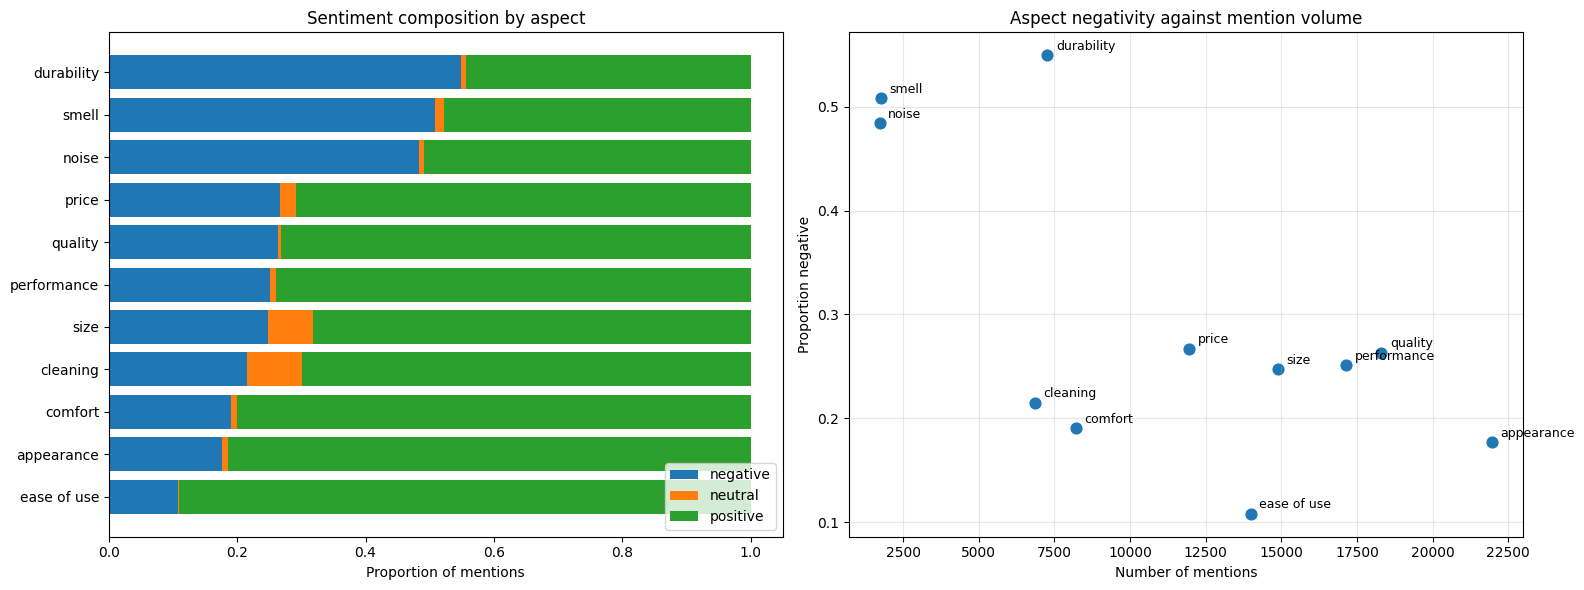

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_aspect_sentiment.png


In [38]:
# Step 20: Visualisation of aspect sentiment
# Two panels are produced. The left panel presents the sentiment composition of
# each aspect, ordered by the proportion of negative sentiment. The right panel
# relates the negativity of each aspect to the volume of mentions, indicating
# which weaknesses are both severe and widespread.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel one: sentiment composition by aspect
plot_order = aspect_summary.sort_values('negative').index
positions = np.arange(len(plot_order))
left_edge = np.zeros(len(plot_order))

for sentiment_class in ['negative', 'neutral', 'positive']:
    values = aspect_summary.loc[plot_order, sentiment_class].values
    axes[0].barh(positions, values, left=left_edge, label=sentiment_class)
    left_edge += values

axes[0].set_yticks(positions)
axes[0].set_yticklabels([name.replace('_', ' ') for name in plot_order])
axes[0].set_xlabel('Proportion of mentions')
axes[0].set_title('Sentiment composition by aspect')
axes[0].legend(loc='lower right')

# Panel two: negativity against mention volume
axes[1].scatter(aspect_summary['mentions'], aspect_summary['negative'], s=60)

for aspect_name in aspect_summary.index:
    axes[1].annotate(aspect_name.replace('_', ' '),
                     (aspect_summary.loc[aspect_name, 'mentions'],
                      aspect_summary.loc[aspect_name, 'negative']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)

axes[1].set_xlabel('Number of mentions')
axes[1].set_ylabel('Proportion negative')
axes[1].set_title('Aspect negativity against mention volume')
axes[1].grid(alpha=0.3)

plt.tight_layout()

aspect_figure_path = f'{output_dir}/fig_aspect_sentiment.png'
plt.savefig(aspect_figure_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", aspect_figure_path)